## Задача 1

Реализовать класс для работы с линейной регрессией

In [344]:
import numpy as np
import pandas as pd

class MyLinearRegression:
    """
    Линейная регрессия с возможностью применения регуляризации и выбора метода вычисления весов.

    Parameters
    ----------
    learning_rate : float, default=0.01
        Скорость обучения для градиентного спуска.

    num_iterations : int, default=1000
        Количество итераций обучения.

    regularization : {'l1', 'l2', 'l1l2', None}, default=None
        Тип регуляризации:
            'l1' - L1 регуляризация,
            'l2' - L2 регуляризация,
            'l1l2' - смешанная регуляризация,
            None - без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Метод вычисления вектора весов:
            'matrix' - матричное вычисление,
            'gd' - градиентный спуск,
            'sgd' - стохастический градиентный спуск.
        При 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    lambda_1 : float, default=None
        Коэффициент регуляризации для L1 или смешанной регуляризации.

    lambda_2 : float, default=None
        Коэффициент регуляризации для L2 или смешанной регуляризации.

    batch_size : int, default=20
        Размер батча для стохастического градиентного спуска.

    Attributes
    ----------
    coefs_ : array, shape (1, n+1)
        Вектор коэффициентов, где n — количество признаков.
        n+1 = количество признаков + фиктивная единичная колонка для смещения.

    feature_names_in_ : array, shape (n+1,)
        Массив из n+1 элемента, где первые n элементов — названия соответствующих признаков, а n+1 элемент — 'bias'.

    Methods
    -------
    fit(X, y, feature_names=None)
        Обучает модель линейной регрессии на данных X и y.

    predict(X, ss=True)
        Предсказывает значения для входных данных X.

    score(X, y)
        Вычисляет коэффициент детерминации (R^2 score) для предсказанных и фактических значений y.

    """
    def __init__(self, learning_rate=0.01, num_iterations=1000, regularization=None, weight_calc='matrix', lambda_1=None, lambda_2=None, batch_size=20):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if (regularization in ['l1', 'l1l2']) and (weight_calc == 'matrix'):
            raise ValueError(f"При regularization равном 'l1' или 'l1l2' нельзя использовать параметр 'matrix'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регуляризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регуляризации l2 не задано")

        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.regularization = regularization
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.weight_calc = weight_calc
        self.batch_size = batch_size
        self.coefs_ = None
        self.feature_names_in_ = None

    def fit(self, X, y, feature_names=None):
        X = np.column_stack((np.ones(len(X)), X.values))
        y = y.values.flatten()

        _, num_features = X.shape

        self.weights = np.zeros(num_features)

        self.feature_names_in_ = feature_names + ['bias'] if feature_names else [f'feature_{i}' for i in range(num_features)]

        if self.weight_calc == 'matrix':
            self.weights = self.update_weights_matrix(X, y)
        else:
            for _ in range(self.num_iterations):

                predictions = np.dot(X, self.weights)

                errors = predictions - y

                if self.weight_calc == 'gd':
                    self.weights = self.update_weights_gd(X, errors)
                elif self.weight_calc == 'sgd':
                    self.weights = self.update_weights_sgd(X, errors)
                else:
                    raise ValueError("Неверное значение для 'weight_calc'. Используйте 'matrix', 'gd', or 'sgd'.")

        self.coefs_ = self.weights

    def update_weights_matrix(self, X, y):
        identity_matrix = np.eye(X.shape[1])  # Единичная матрица размера (количество признаков + 1) x (количество признаков + 1)
        # вычисляем веса beta: обратная матрица @ транспонированную матрицу
        beta = np.linalg.inv(X.T @ X + self.lambda_2 * identity_matrix) @ X.T @ y

        return beta

    def update_weights_gd(self, X, errors):
        gradient = np.dot(X.T, errors)

        if self.regularization == 'l1':
            regularization_term = self.lambda_1 * np.sign(self.weights) # np.sign() возвращает вектор знаков весов
        elif self.regularization == 'l2':
            regularization_term = 2 * self.lambda_2 * self.weights
        elif self.regularization == 'l1l2':
            regularization_term = self.lambda_1 * np.sign(self.weights) + 2 * self.lambda_2 * self.weights
        else:
            regularization_term = 0

        self.weights -= (self.learning_rate / len(errors)) * (gradient + regularization_term)

        return self.weights

    def predict(self, X, ss=True):
        X = np.column_stack((np.ones(len(X)), X)) if ss else X
        weights = self.weights if ss else self.weights[1:]
        return np.dot(X, weights)

    def score(self, X, y):
        y_pred = self.predict(X)
        mean_y = np.mean(y)
        ss_total = np.sum((y - mean_y)**2)
        ss_residual = np.sum((y - y_pred)**2)
        r2_score = 1 - (ss_residual / ss_total)
        return r2_score

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы.

In [341]:
link = 'Used_fiat_500_in_Italy_dataset.csv'
data = pd.read_csv(link)
data.head()

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790


Веса: [ 5797.37921957    47.35404215 -1493.04189585  -589.3024795
    50.0570476    177.91208851   235.09357518]
R^2 Score: 0.891471150823152


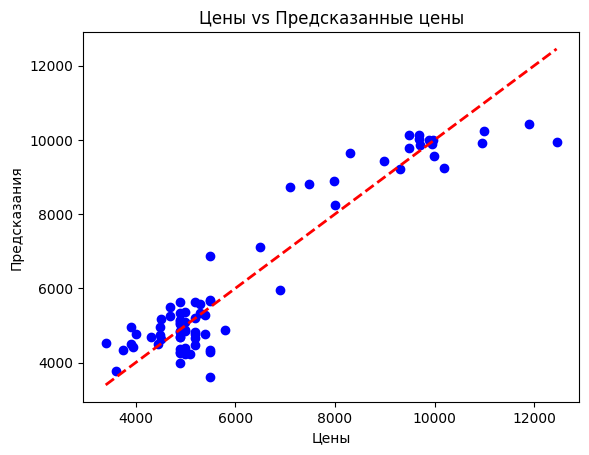

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Used_fiat_500_in_Italy_dataset.csv')

numerical_features = ['engine_power', 'age_in_days', 'km', 'previous_owners', 'lat', 'lon']
target_variable = 'price'

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

scaler = StandardScaler()
train_data[numerical_features] = scaler.fit_transform(train_data[numerical_features])
test_data[numerical_features] = scaler.transform(test_data[numerical_features])

lr = MyLinearRegression(learning_rate=0.001, num_iterations=10000, regularization='l1', lambda_1=0.1, weight_calc='gd', batch_size=10)
lr.fit(train_data[numerical_features], train_data[target_variable])

print("Веса:", lr.coefs_)

y_pred = lr.predict(test_data[numerical_features])

r2 = lr.score(test_data[numerical_features], test_data[target_variable])
print("R^2 Score:", r2)

plt.scatter(test_data[target_variable], y_pred, color='blue')
plt.plot([min(test_data[target_variable]), max(test_data[target_variable])], [min(test_data[target_variable]), max(test_data[target_variable])], linestyle='--', color='red', linewidth=2)
plt.xlabel('Цены')
plt.ylabel('Предсказания')
plt.title('Цены vs Предсказанные цены')
plt.show()

## Задача 2

[Соревнование на Kaggle](https://www.kaggle.com/competitions/stat-plus-ml-2024)

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
random_seed = 42

In [27]:
train_data = pd.read_csv("train_contest.csv", header=0)
train_data

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30067,False,Руководитель отдела персонала,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Ленинградский пр...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Управле...,"{'id': 'moreThan6', 'name': 'Более 6 лет'}","[{'name': 'Подбор персонала'}, {'name': 'Адапт...","[{'id': '9.738', 'name': 'Другое', 'profarea_i...",Москва,NaN,190000.0
30068,False,Специалист по развитию и обучению персонала,NaN,False,False,"{'id': '1641', 'name': 'Набережные Челны', 'ur...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Набережные Челны', 'street': 'проспе...",NaN,NaN,...,[],[],False,<p>Группа компаний &quot;Бринэкс&quot; приглаш...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Управление временем'}, {'name': 'Ор...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Республика Татарстан,NaN,45000.0
30069,False,Инженер-программист,NaN,False,False,"{'id': '1399', 'name': 'Магнитогорск', 'url': ...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'SQL'}, {'name': 'Работа с базами да...","[{'id': '1.221', 'name': 'Программирование, Ра...",Челябинская область,NaN,75000.0
30070,False,Куратор проекта,"{'id': '1947314-1947314-ancor', 'name': 'ANCOR'}",False,False,"{'id': '3', 'name': 'Екатеринбург', 'url': 'ht...","{'id': 'open', 'name': 'Откр

In [31]:
train_data.isna().sum()

premium                         0
name                            0
department                  29320
has_test                        0
response_letter_required        0
area                            0
type                            0
address                     10967
response_url                30072
sort_point_distance         30072
published_at                    0
created_at                      0
archived                        0
insider_interview           29978
url                             0
alternate_url                   0
relations                       0
employer                        0
snippet                         0
contacts                    10987
schedule                        0
working_days                    0
working_time_intervals          0
working_time_modes              0
accept_temporary                0
description                     0
experience                      0
key_skills                      0
specializations                 0
region        

In [41]:
train_data_clear = train_data.dropna(axis=1)

Index(['premium', 'name', 'has_test', 'response_letter_required', 'area',
       'type', 'published_at', 'created_at', 'archived', 'url',
       'alternate_url', 'relations', 'employer', 'snippet', 'schedule',
       'working_days', 'working_time_intervals', 'working_time_modes',
       'accept_temporary', 'description', 'experience', 'key_skills',
       'specializations', 'region', 'mean_salary'],
      dtype='object')

In [42]:
train_data_clear

,premium,name,has_test,response_letter_required,area,type,published_at,created_at,archived,url,...,working_days,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,mean_salary
0,False,Агент по недвижимости,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}",2022-05-26T09:09:14+0300,2022-05-26T09:09:14+0300,False,https://api.hh.ru/vacancies/46446173?host=hh.ru,...,[],[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,125000.0
1,False,IT-специалист/ техник,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",2022-05-19T04:34:12+0300,2022-05-19T04:34:12+0300,False,https://api.hh.ru/vacancies/55538441?host=hh.ru,...,[],[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,50000.0
2,False,Старший/ведущий инженер-программист,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}",2022-05-25T10:39:22+0300,2022-05-25T10:39:22+0300,False,https://api.hh.ru/vacancies/54445542?host=hh.ru,...,[],[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,80000.0
3,False,Эксперт / методист приемной комиссии,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",2022-05-04T11:15:38+0300,2022-05-04T11:15:38+0300,False,https://api.hh.ru/vacancies/54674107?host=hh.ru,...,[],[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,120000.0
4,False,Табельщица/табельщик,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}",2022-05-23T07:00:36+0300,2022-05-23T07:00:36+0300,False,https://api.hh.ru/vacancies/47298310?host=hh.ru,...,[],[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,15000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30067,False,Руководитель отдела персонала,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",2022-05-20T14:07:16+0300,2022-05-20T14:07:16+0300,False,https://api.hh.ru/vacancies/55203409?host=hh.ru,...,[],[],[],False,<strong>Обязанности:</strong> <ul> <li>Управле...,"{'id': 'moreThan6', 'name': 'Более 6 лет'}","[{'name': 'Подбор персонала'}, {'name': 'Адапт...","[{'id': '9.738', 'name': 'Другое', 'profarea_i...",Москва,190000.0
30068,False,Специалист по развитию и обучению персонала,False,False,"{'id': '1641', 'name': 'Набережные Челны', 'ur...","{'id': 'open', 'name': 'Открытая'}",2022-05-20T11:28:35+0300,2022-05-20T11:28:35+0300,False,https://api.hh.ru/vacancies/55581773?host=hh.ru,...,[],[],[],False,<p>Группа компаний &quot;Бринэкс&quot; приглаш...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Управление временем'}, {'name': 'Ор...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Республика Татарстан,45000.0
30069,False,Инженер-программист,False,False,"{'id': '1399', 'name': 'Магнитогорск', 'url': ...","{'id': 'open', 'name': 'Открытая'}",2022-05-11T10:18:46+0300,2022-05-11T10:18:46+0300,False,https://api.hh.ru/vacancies/54792750?host=hh.ru,...,[],[],[],False,<strong>Обязанности:</s

In [44]:
train_data_clear['type'].describe()

count                                  30072
unique                                     2
top       {'id': 'open', 'name': 'Открытая'}
freq                                   30025
Name: type, dtype: object

In [58]:
print(train_data_clear['working_days'].describe())
print(train_data_clear['working_time_intervals'].describe())
train_data_clear['working_time_modes'].describe()

count     30072
unique        2
top          []
freq      29873
Name: working_days, dtype: object
count     30072
unique        2
top          []
freq      29039
Name: working_time_intervals, dtype: object


count     30072
unique        2
top          []
freq      29489
Name: working_time_modes, dtype: object

In [45]:
train_data_clear.columns

Index(['premium', 'name', 'has_test', 'response_letter_required', 'area',
       'type', 'published_at', 'created_at', 'archived', 'url',
       'alternate_url', 'relations', 'employer', 'snippet', 'schedule',
       'working_days', 'working_time_intervals', 'working_time_modes',
       'accept_temporary', 'description', 'experience', 'key_skills',
       'specializations', 'region', 'mean_salary'],
      dtype='object')

In [407]:
train_data_tuned = train_data_clear.drop(columns=['type', 'published_at', 'created_at', 'archived', 'url', 'alternate_url', 'description', 'snippet', 'key_skills', 'relations', 'specializations'])

In [408]:
train_data_tuned

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region,mean_salary
0,False,Агент по недвижимости,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}",[],[],[],False,"{'id': 'noExperience', 'name': 'Нет опыта'}",Санкт-Петербург,125000.0
1,False,IT-специалист/ техник,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Иркутская область,50000.0
2,False,Старший/ведущий инженер-программист,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Ростовская область,80000.0
3,False,Эксперт / методист приемной комиссии,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Москва,120000.0
4,False,Табельщица/табельщик,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Саратовская область,15000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30067,False,Руководитель отдела персонала,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '127256', 'name': 'СИНЕРГИЯ', 'url': 'h...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'moreThan6', 'name': 'Более 6 лет'}",Москва,190000.0
30068,False,Специалист по развитию и обучению персонала,False,False,"{'id': '1641', 'name': 'Набережные Челны', 'ur...","{'id': '1068750', 'name': 'Brinex', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Республика Татарстан,45000.0
30069,False,Инженер-программист,False,False,"{'id': '1399', 'name': 'Магнитогорск', 'url': ...","{'id': '824486', 'name': 'Магнитогорский метал...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Челябинская область,75000.0
30070,False,Куратор проекта,False,False,"{'id': '3', 'name': 'Екатеринбург', 'url': 'ht...","{'id': '1947314', 'name': 'ANCOR', 'url': 'htt...","{'id': 'flexible', 'name': 'Гибкий график'}",[],"[{'id': 'from_four_to_six_hours_in_a_day', 'na...",[],True,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Свердловская область,30000.0


In [409]:
train_data_tuned['employer'][1]

"{'id': '1136625', 'name': 'СМП-38', 'url': 'https://api.hh.ru/employers/1136625', 'alternate_url': 'https://hh.ru/employer/1136625', 'logo_urls': {'240': 'https://hhcdn.ru/employer-logo/3859496.png', '90': 'https://hhcdn.ru/employer-logo/3859495.png', 'original': 'https://hhcdn.ru/employer-logo-original/854655.png'}, 'vacancies_url': 'https://api.hh.ru/vacancies?employer_id=1136625', 'trusted': True}"

In [249]:
#train_data_tuned['specializations'][1]

In [410]:
import json
import re

train_data_replaced = train_data_tuned.copy()

def safe_json_loads(x):
    try:
        if isinstance(x, str):
            x = x.replace("'", '"')
            return json.loads(x)
        return ""
    except Exception as e:
        return ""
    
train_data_replaced['area'] = train_data_replaced['area'].apply(lambda x: x.replace("'", '"')).apply(json.loads).apply(lambda x: int(x['id']))
train_data_replaced['employer'] = (train_data_replaced['employer']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: int(x['id']) if 'id' in x else 0))
train_data_replaced['schedule'] = (train_data_replaced['schedule']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: x['id'] if 'id' in x else ""))
train_data_replaced['experience'] = (train_data_replaced['experience']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: x['id'] if 'id' in x else ""))
#train_data_replaced['specializations'] = train_data_replaced['specializations'].apply(lambda x: x.replace("'", '"')).apply(json.loads).apply(lambda x: [item['id'] for item in x]).apply(lambda x: ', '.join(x))

In [411]:
train_data_replaced

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region,mean_salary
0,False,Агент по недвижимости,False,False,2,541016,flexible,[],[],[],False,noExperience,Санкт-Петербург,125000.0
1,False,IT-специалист/ техник,False,False,1130,1136625,flyInFlyOut,[],[],[],False,between1And3,Иркутская область,50000.0
2,False,Старший/ведущий инженер-программист,False,False,76,611346,fullDay,[],[],[],False,between1And3,Ростовская область,80000.0
3,False,Эксперт / методист приемной комиссии,False,False,1,171255,fullDay,[],[],[],False,between1And3,Москва,120000.0
4,False,Табельщица/табельщик,False,False,1613,617150,fullDay,[],[],[],False,between1And3,Саратовская область,15000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30067,False,Руководитель отдела персонала,False,False,1,127256,fullDay,[],[],[],False,moreThan6,Москва,190000.0
30068,False,Специалист по развитию и обучению персонала,False,False,1641,1068750,fullDay,[],[],[],False,between1And3,Республика Татарстан,45000.0
30069,False,Инженер-программист,False,False,1399,824486,fullDay,[],[],[],False,between1And3,Челябинская область,75000.0
30070,False,Куратор проекта,False,False,3,1947314,flexible,[],"[{'id': 'from_four_to_six_hours_in_a_day', 'na...",[],True,between1And3,Свердловская область,30000.0


In [307]:
from sklearn.preprocessing import LabelEncoder

In [412]:
import pandas as pd

target_column = 'mean_salary'

train_data_coded = train_data_replaced.copy()

for column in ['name', 'schedule', 'experience', 'region', 'working_time_intervals', 'working_time_modes', 'working_days', 'premium', 'has_test', 'response_letter_required', 'accept_temporary']:

    mean_encoded = train_data_replaced.groupby(column)[target_column].mean()
    
    train_data_coded[column] = train_data_replaced[column].map(mean_encoded)
    
    train_data_coded[column] = train_data_coded[column].fillna(train_data_replaced[target_column].mean())


In [413]:
train_data_coded

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region,mean_salary
0,97573.639022,141850.671141,97215.141518,97650.927849,2,541016,112549.626543,97860.784371,98259.486053,98007.596612,96228.405966,87182.020430,114247.058773,125000.0
1,97573.639022,50000.000000,97215.141518,97650.927849,1130,1136625,102165.095745,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,67871.897862,50000.0
2,97573.639022,80000.000000,97215.141518,97650.927849,76,611346,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,79473.988399,80000.0
3,97573.639022,120000.000000,97215.141518,97650.927849,1,171255,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,134738.590843,120000.0
4,97573.639022,15000.000000,97215.141518,97650.927849,1613,617150,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,82187.237237,15000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30067,97573.639022,87232.558140,97215.141518,97650.927849,1,127256,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,184829.037879,134738.590843,190000.0
30068,97573.639022,47500.000000,97215.141518,97650.927849,1641,1068750,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,89604.929833,45000.0
30069,97573.639022,57077.840659,97215.141518,97650.927849,1399,824486,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,68559.883275,75000.0
30070,97573.639022,30000.000000,97215.141518,97650.927849,3,1947314,112549.626543,97860.784371,82794.526621,98007.596612,112245.216087,83062.969576,89009.937179,30000.0


In [414]:
X = train_data_coded.drop(columns=['mean_salary'])
y = train_data_coded['mean_salary']

In [415]:
print(train_data_coded.dtypes)

premium                     float64
name                        float64
has_test                    float64
response_letter_required    float64
area                          int64
employer                      int64
schedule                    float64
working_days                float64
working_time_intervals      float64
working_time_modes          float64
accept_temporary            float64
experience                  float64
region                      float64
mean_salary                 float64
dtype: object


In [416]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [417]:
from sklearn.linear_model import Ridge, Lasso

In [418]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

model = Lasso(13)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(scaler.transform(X_test))

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 2421935810.809298


## Предсказание

In [359]:
test_data = pd.read_csv("for_prediction.csv", header=0, index_col='Id')

In [360]:
test_data

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_days,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url
Id,,,,,,,,,,,,,,,,,,,,,
0,False,Помощник маркетолога,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],[],False,<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","[{'id': '3.206', 'name': 'Печатная реклама', '...",Москва,NaN
1,False,Менеджер по персоналу,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Новочер...",NaN,NaN,...,[],[],[],False,<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Санкт-Петербург,NaN
2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",NaN,False,False,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Уфа', 'street': 'Рубежная улица', 'b...",NaN,NaN,...,[],[],[],False,"<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'noExperience', 'name': 'Нет опыта'}",[],"[{'id': '24.378', 'name': 'Тренерский состав',...",Республика Башкортостан,NaN
3,False,Программист Delphi,NaN,False,False,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],[],False,<p>Компания AMS Software - разработчик популяр...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","[{'id': '1.221', 'name': 'Программирование, Ра...",Новосибирская область,NaN
4,False,Ведущий специалист ВКС,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Чистопрудный бул...",NaN,NaN,...,[],[],[],False,<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","[{'id': '1.172', 'name': 'Начальный уровень, М...",Москва,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7513,False,HR менеджер,NaN,False,False,"{'id': '131', 'name': 'Симферополь', 'url': 'h...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Симферополь', 'street': 'улица Жени ...",NaN,NaN,...,[],[],[],False,<strong>Обязанности:</strong> <ul> <li>Поиск и...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Подбор персонала'}, {'name': 'Работ...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Республика Крым,NaN
7514,False,Руководитель HR отдела,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Электрический пе...",NaN,NaN,...,[],[],[],False,<strong>Обязанности:</strong> <ul> <li>Организ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Ведение отчетности'}, {'name': 'Вед...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Москва,NaN
7515,False,Системный аналитик (Стажер),"{'id': '80-80-bank', 'name': ' Альфа-Банк'}",False,False,"{'id': '3', 'name': 'Екатеринбург', 'url': 'ht...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Екатеринбург', 'street': 'Горького',...",NaN,NaN,...,[],[],[],False,<p>Альфа-Банк — крупнейший частный банк России...,"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Разработка технических заданий'}, {...","[{'id': '17.751', 'name': 'Другое', 'profarea_...",Свердловская область,NaN


In [419]:
test_data_tuned = test_data.drop(columns=['type', 'published_at', 'created_at', 'archived', 'url', 'alternate_url', 'description', 'snippet', 'key_skills', 'relations', 'department', 'address', 'response_url',
                                          'sort_point_distance', 'insider_interview', 'contacts', 'immediate_redirect_url', 'specializations'])

In [420]:
test_data_tuned.columns

Index(['premium', 'name', 'has_test', 'response_letter_required', 'area',
       'employer', 'schedule', 'working_days', 'working_time_intervals',
       'working_time_modes', 'accept_temporary', 'experience', 'region'],
      dtype='object')

In [421]:
test_data_tuned

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region
Id,,,,,,,,,,,,,
0,False,Помощник маркетолога,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Москва
1,False,Менеджер по персоналу,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'noExperience', 'name': 'Нет опыта'}",Санкт-Петербург
2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",False,False,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'noExperience', 'name': 'Нет опыта'}",Республика Башкортостан
3,False,Программист Delphi,False,False,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}",[],[],[],False,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}",Новосибирская область
4,False,Ведущий специалист ВКС,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Москва
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7513,False,HR менеджер,False,False,"{'id': '131', 'name': 'Симферополь', 'url': 'h...","{'id': '2130866', 'name': 'Группа компаний She...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Республика Крым
7514,False,Руководитель HR отдела,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '1247171', 'name': 'Edison', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}",[],[],[],False,"{'id': 'between1And3', 'name': 'От 1 года до 3...",Москва
7515,False,Системный аналитик (Стажер),False,False,"{'id': '3', 'name': 'Екатеринбург', 'url': 'ht...","{'id': '80', 'name': 'Альфа-Банк', 'url': 'htt...","{'id': 'flexible', 'name': 'Гибкий график'}",[],[],[],False,"{'id': 'noExperience', 'name': 'Нет опыта'}",Свердловская область


In [423]:
test_data_replaced = test_data_tuned.copy()

def safe_json_loads(x):
    try:
        if isinstance(x, str):
            x = x.replace("'", '"')
            return json.loads(x)
        return ""
    except Exception as e:
        return ""
    
test_data_replaced['area'] = test_data_replaced['area'].apply(lambda x: x.replace("'", '"')).apply(json.loads).apply(lambda x: int(x['id']))
test_data_replaced['employer'] = (test_data_replaced['employer']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: int(x['id']) if 'id' in x else 0))
test_data_replaced['schedule'] = (test_data_replaced['schedule']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: x['id'] if 'id' in x else ""))
test_data_replaced['experience'] = (test_data_replaced['experience']
                                   .apply(lambda x: x.replace("True","true").replace("False", "false").replace("None", "null").replace("\\xa0", "").replace(":'", ":\"").replace("',", "\","))
                                   .apply(safe_json_loads)
                                   .apply(lambda x: x['id'] if 'id' in x else ""))
#test_data_replaced['specializations'] = test_data_replaced['specializations'].apply(lambda x: x.replace("'", '"')).apply(json.loads).apply(lambda x: [item['id'] for item in x]).apply(lambda x: ', '.join(x))

In [424]:
test_data_replaced

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region
Id,,,,,,,,,,,,,
0,False,Помощник маркетолога,False,False,1,2710310,remote,[],[],[],False,between1And3,Москва
1,False,Менеджер по персоналу,False,False,2,52824,fullDay,[],[],[],False,noExperience,Санкт-Петербург
2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",False,False,99,230048,fullDay,[],[],[],False,noExperience,Республика Башкортостан
3,False,Программист Delphi,False,False,4,634253,remote,[],[],[],False,between3And6,Новосибирская область
4,False,Ведущий специалист ВКС,False,False,1,36889,fullDay,[],[],[],False,between1And3,Москва
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7513,False,HR менеджер,False,False,131,2130866,fullDay,[],[],[],False,between1And3,Республика Крым
7514,False,Руководитель HR отдела,False,False,1,1247171,fullDay,[],[],[],False,between1And3,Москва
7515,False,Системный аналитик (Стажер),False,False,3,80,flexible,[],[],[],False,noExperience,Свердловская область


In [425]:
test_data_coded = test_data_replaced.copy()

for column in ['name', 'schedule', 'experience', 'region', 'working_time_intervals', 'working_time_modes', 'working_days', 'premium', 'has_test', 'response_letter_required', 'accept_temporary']:

    mean_encoded = train_data_replaced.groupby(column)[target_column].mean()
    
    test_data_coded[column] = test_data_replaced[column].map(mean_encoded)
    
    test_data_coded[column] = test_data_coded[column].fillna(train_data_replaced[target_column].mean())


In [426]:
test_data_coded

,premium,name,has_test,response_letter_required,area,employer,schedule,working_days,working_time_intervals,working_time_modes,accept_temporary,experience,region
Id,,,,,,,,,,,,,
0,97573.639022,31450.000000,97215.141518,97650.927849,1,2710310,114989.900197,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,134738.590843
1,97573.639022,46406.845794,97215.141518,97650.927849,2,52824,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,87182.020430,114247.058773
2,97573.639022,25200.000000,97215.141518,97650.927849,99,230048,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,87182.020430,68433.571429
3,97573.639022,110875.000000,97215.141518,97650.927849,4,634253,114989.900197,97860.784371,98259.486053,98007.596612,96228.405966,137068.742919,106697.788754
4,97573.639022,97728.250914,97215.141518,97650.927849,1,36889,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,134738.590843
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7513,97573.639022,59213.961039,97215.141518,97650.927849,131,2130866,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,73119.484424
7514,97573.639022,97728.250914,97215.141518,97650.927849,1,1247171,94336.102307,97860.784371,98259.486053,98007.596612,96228.405966,83062.969576,134738.590843
7515,97573.639022,97728.250914,97215.141518,97650.927849,3,80,112549.626543,97860.784371,98259.486053,98007.596612,96228.405966,87182.020430,89009.937179


In [427]:
test_data_min_max = scaler.transform(test_data_coded)

In [428]:
predictions = model.predict(test_data_min_max)

In [429]:
print(predictions)

[ 43261.28242938  51916.4623895   18845.88357125 ...  95628.8767237
  89262.21451762 114348.77604222]


In [430]:
test_data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       7508, 7509, 7510, 7511, 7512, 7513, 7514, 7515, 7516, 7517],
      dtype='int64', name='Id', length=7518)

In [432]:
result = pd.DataFrame({
    'Id': test_data.index,
    'Prediction': predictions
})

result.to_csv('predictions.csv', index=False)